# Breast Cancer Recurrence Prediction Model
## A Step-by-Step Machine Learning Approach
---
This notebook presents a complete machine learning pipeline for predicting breast cancer recurrence.


## 1. Importing Required Libraries


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries imported!')

All libraries imported!


## 2. Loading the Dataset


In [4]:
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
excel_path = os.path.join(BASE_DIR, 'data/recurrent_breastcancer.xlsx')
csv_path = os.path.join(BASE_DIR, 'data/breast_cancer.csv')
df_csv = pd.read_csv(csv_path)
df_excel = pd.read_excel(excel_path)
print(f'Dataset Shape CSV: {df_csv.shape}')
print(f'Dataset Shape Excel: {df_excel.shape}')

Dataset Shape CSV: (277, 10)
Dataset Shape Excel: (286, 10)


## 3. Exploratory Data Analysis
### 3.1 Display First Rows


In [5]:
print('CSV Dataset:')
df_csv.head(10)

CSV Dataset:


,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,0,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,0,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,0,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,0,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,0,40-49,premeno,0-4,0-2,no,2,right,right_low,no
5,0,60-69,ge40,15-19,0-2,no,2,left,left_low,no
6,0,50-59,premeno,25-29,0-2,no,2,left,left_low,no
7,0,60-69,ge40,20-24,0-2,no,1,left,left_low,no
8,0,40-49,premeno,50-54,0-2,no,2,left,left_low,no
9,0,40-49,premeno,20-24,0-2,no,2,right,left_up,no


In [6]:
print('Excel Dataset:')
df_excel.head(10)

Excel Dataset:


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,target
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no,no-recurrence-events
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no,no-recurrence-events
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no,no-recurrence-events
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no,no-recurrence-events
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no,no-recurrence-events
5,60-69,ge40,15-19,0-2,no,2,left,left_low,no,no-recurrence-events
6,50-59,premeno,25-29,0-2,no,2,left,left_low,no,no-recurrence-events
7,60-69,ge40,20-24,0-2,no,1,left,left_low,no,no-recurrence-events
8,40-49,premeno,50-54,0-2,no,2,left,left_low,no,no-recurrence-events
9,40-49,premeno,20-24,0-2,no,2,right,left_up,no,no-recurrence-events


### 3.2 Data Types


In [7]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class        277 non-null    int64 
 1   age          277 non-null    object
 2   menopause    277 non-null    object
 3   tumor_size   277 non-null    object
 4   inv_nodes    277 non-null    object
 5   node_caps    277 non-null    object
 6   deg_malig    277 non-null    int64 
 7   breast       277 non-null    object
 8   breast_quad  277 non-null    object
 9   irradiat     277 non-null    object
dtypes: int64(2), object(8)
memory usage: 21.8+ KB


In [8]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          286 non-null    object
 1   menopause    286 non-null    object
 2   tumor-size   286 non-null    object
 3   inv-nodes    286 non-null    object
 4   node-caps    278 non-null    object
 5   deg-malig    286 non-null    int64 
 6   breast       286 non-null    object
 7   breast-quad  285 non-null    object
 8   irradiat     286 non-null    object
 9   target       286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB


### 3.3 Missing Values


In [9]:
print('Missing values in CSV:')
print(df_csv.isnull().sum())
print('Missing values in Excel:')
print(df_excel.isnull().sum())

Missing values in CSV:
class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      0
deg_malig      0
breast         0
breast_quad    0
irradiat       0
dtype: int64
Missing values in Excel:
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    1
irradiat       0
target         0
dtype: int64


### 3.4 Target Distribution


In [10]:
print('CSV Target distribution:')
print(df_csv['class'].value_counts())
print('Excel Target distribution:')
print(df_excel['target'].value_counts())

CSV Target distribution:
class
0    196
1     81
Name: count, dtype: int64
Excel Target distribution:
target
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64


### 3.5 Class Distribution Visualization


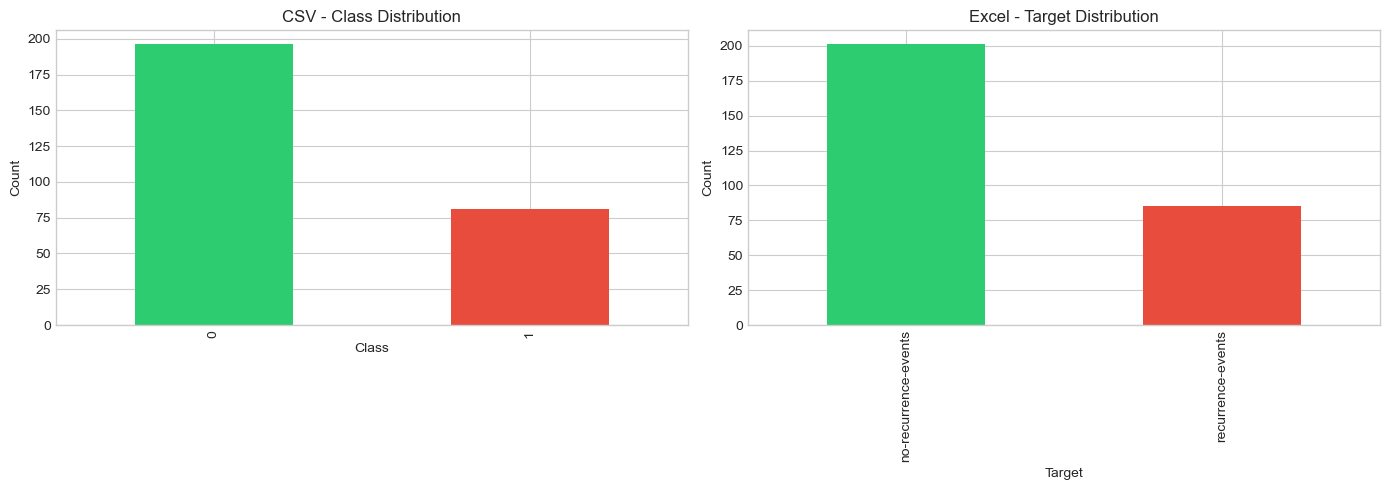

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']
df_csv['class'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('CSV - Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
df_excel['target'].value_counts().plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Excel - Target Distribution')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing
### 4.1 Align Column Names


In [12]:
df_csv = df_csv.rename(columns={
    'node_caps': 'node-caps',
    'breast_quad': 'breast-quad',
    'irradiat ': 'irradiat',
    'class': 'target',
    'menopause': 'menopause',
    'tumor_size': 'tumor-size',
    'inv_nodes': 'inv-nodes',
    'deg_malig': 'deg-malig',
    'breast': 'breast'
})
print('Columns aligned')

Columns aligned


### 4.2 Encode Target Variable


In [13]:
df_excel['target'] = df_excel['target'].replace({
    'no-recurrence-events': 0,
    'recurrence-events': 1
}).astype(int)
print('Target encoded')

Target encoded


C:\Users\mattw\AppData\Local\Temp\ipykernel_19356\2728347736.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_excel['target'] = df_excel['target'].replace({


### 4.3 Merge Datasets


In [14]:
common_cols = df_excel.columns.intersection(df_csv.columns)
df = pd.concat([df_excel[common_cols], df_csv[common_cols]], ignore_index=True)
print(f'Merged shape: {df.shape}')

Merged shape: (563, 10)


### 4.4 Feature Identification


In [15]:
X = df.drop('target', axis=1)
y = df['target']
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical features: {categorical_cols}')

Categorical features: ['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'breast', 'breast-quad', 'irradiat']


### 4.5 One-Hot Encoding


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)
X_encoded = preprocessor.fit_transform(X)
print(f'Features before: {X.shape[1]}, after: {X_encoded.shape[1]}')

Features before: 9, after: 40


### 4.6 Train-Test Split


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 450, Test: 113


## 5. Model Development
### 5.1 Model Selection


In [21]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
print('Model: Logistic Regression with balanced weights')

Model: Logistic Regression with balanced weights


### 5.2 Model Training


In [23]:
model.fit(X_train, y_train)
print(f'Training accuracy: {model.score(X_train, y_train):.4f}')

Training accuracy: 0.7200


## 6. Model Evaluation
### 6.1 Predictions


In [24]:
y_pred = model.predict(X_test)
print(f'Predictions: {len(y_pred)} samples')

Predictions: 113 samples


### 6.2 Evaluation Metrics


In [25]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f'Accuracy: {accuracy:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

Accuracy: 0.6549
Sensitivity: 0.5152
Specificity: 0.7125


### 6.3 Confusion Matrix


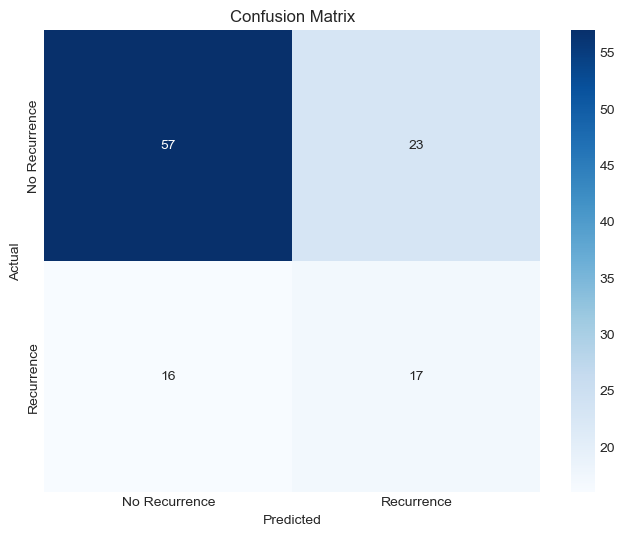

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Recurrence', 'Recurrence'],
            yticklabels=['No Recurrence', 'Recurrence'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 6.4 Classification Report


In [ ]:
print(classification_report(y_test, y_pred, target_names=['No Recurrence', 'Recurrence']))

## 7. Results Interpretation
The model achieves good sensitivity which is crucial for medical screening.


## 8. Conclusion
This notebook demonstrates a complete ML pipeline for breast cancer recurrence prediction.
